# Chapter 16 Python Lab  
## Triple Integrals and Geometry in $\mathbb R^3$

This lab accompanies **Chapter 16: Triple Integrals and Geometry in $\mathbb R^3$**.

A triple integral adds up a quantity over a three-dimensional region:

$$
\iiint_E f(x,y,z)\,dV.
$$

When $f=1$, the triple integral gives volume:

$$
\operatorname{Vol}(E)=\iiint_E 1\,dV.
$$

When $f$ is a density, the triple integral gives mass.  
When $f$ is a probability density, it gives probability.

This lab uses Python to explore:

- Riemann sums in three dimensions;
- triple integrals over rectangular boxes;
- iterated integrals and order of integration;
- solids between surfaces;
- volume, mass, average value, and center of mass;
- slicing solids by horizontal or vertical planes;
- Monte Carlo integration in 3D;
- density and probability over spatial regions;
- numerical checks for geometric formulas;
- and computational visualization of solids in $\mathbb R^3$.

Only `numpy` and `matplotlib` are required.

## Learning goals

By the end of this lab, you should be able to:

1. approximate triple integrals with midpoint Riemann sums;
2. interpret $dV$ as a small volume element;
3. compute iterated integrals over boxes;
4. describe solids using inequalities and masks;
5. compute volumes of boxes, tetrahedra, balls, cylinders, cones, and regions between surfaces;
6. compute mass from a density function;
7. compute center of mass of simple solids;
8. estimate average value over a solid;
9. use Monte Carlo methods for 3D integration;
10. connect triple integrals with probability and data-defined 3D regions.

## Source note

This notebook was generated from the uploaded Chapter 16 QMD file.  
The extracted early headings from the source file include:

- Learning goals
- 16.1 From double integrals to triple integrals
- The guiding picture
- Draw a small stack of boxes that suggest a voxel approximation.
- 16.2 Volume as a triple integral
- Volume of a solid
- Example 16.1: A rectangular box
- 16.3 Solids between two surfaces
- Projection-first method
- projection boundary
- Example 16.2: Volume under a plane over a triangle
- 16.4 Integrating functions over solids
- Example 16.3: A triple integral over the standard tetrahedron
- 16.5 Mass and density in three dimensions

## 0. Setup

Run this cell first.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

np.set_printoptions(precision=6, suppress=True)

def safe_eval_3d(f, X, Y, Z):
    with np.errstate(divide="ignore", invalid="ignore", over="ignore", under="ignore"):
        W = f(X, Y, Z)
    return np.asarray(W, dtype=float)

def make_grid2d(xmin, xmax, ymin, ymax, n=200):
    x = np.linspace(xmin, xmax, n)
    y = np.linspace(ymin, ymax, n)
    X, Y = np.meshgrid(x, y)
    return x, y, X, Y

def make_3d_axes(title=None, elev=25, azim=45):
    fig = plt.figure(figsize=(7, 6))
    ax = fig.add_subplot(111, projection="3d")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_zlabel("z")
    if title:
        ax.set_title(title)
    ax.view_init(elev=elev, azim=azim)
    return fig, ax

def midpoint_box(f, xmin, xmax, ymin, ymax, zmin, zmax, nx=40, ny=40, nz=40):
    dx = (xmax - xmin)/nx
    dy = (ymax - ymin)/ny
    dz = (zmax - zmin)/nz
    xmid = xmin + (np.arange(nx) + 0.5)*dx
    ymid = ymin + (np.arange(ny) + 0.5)*dy
    zmid = zmin + (np.arange(nz) + 0.5)*dz
    X, Y, Z = np.meshgrid(xmid, ymid, zmid, indexing="ij")
    W = safe_eval_3d(f, X, Y, Z)
    return float(np.sum(W)*dx*dy*dz), X, Y, Z, W, dx, dy, dz

def midpoint_solid_mask(f, xmin, xmax, ymin, ymax, zmin, zmax, mask, nx=60, ny=60, nz=60):
    dx = (xmax - xmin)/nx
    dy = (ymax - ymin)/ny
    dz = (zmax - zmin)/nz
    xmid = xmin + (np.arange(nx) + 0.5)*dx
    ymid = ymin + (np.arange(ny) + 0.5)*dy
    zmid = zmin + (np.arange(nz) + 0.5)*dz
    X, Y, Z = np.meshgrid(xmid, ymid, zmid, indexing="ij")
    inside = mask(X, Y, Z)
    W = safe_eval_3d(f, X, Y, Z)
    return float(np.sum(W[inside])*dx*dy*dz), X, Y, Z, W, inside, dx, dy, dz

def monte_carlo_solid(f, xmin, xmax, ymin, ymax, zmin, zmax, mask=None, n=100_000, seed=0):
    rng = np.random.default_rng(seed)
    X = rng.uniform(xmin, xmax, n)
    Y = rng.uniform(ymin, ymax, n)
    Z = rng.uniform(zmin, zmax, n)
    box_volume = (xmax - xmin)*(ymax - ymin)*(zmax - zmin)
    if mask is None:
        values = safe_eval_3d(f, X, Y, Z)
        estimate = box_volume*np.mean(values)
        standard_error = box_volume*np.std(values, ddof=1)/np.sqrt(n)
        inside = np.ones(n, dtype=bool)
        return float(estimate), float(standard_error), X, Y, Z, inside, values
    inside = mask(X, Y, Z)
    values = np.zeros(n, dtype=float)
    values[inside] = safe_eval_3d(f, X[inside], Y[inside], Z[inside])
    estimate = box_volume*np.mean(values)
    standard_error = box_volume*np.std(values, ddof=1)/np.sqrt(n)
    return float(estimate), float(standard_error), X, Y, Z, inside, values

def integrate_between_surfaces(f_xyz, xmin, xmax, ymin, ymax, z_lower, z_upper,
                               mask_xy=None, nx=160, ny=160, nz=80):
    dx = (xmax - xmin)/nx
    dy = (ymax - ymin)/ny
    xmid = xmin + (np.arange(nx) + 0.5)*dx
    ymid = ymin + (np.arange(ny) + 0.5)*dy
    total = 0.0
    for x0 in xmid:
        for y0 in ymid:
            if mask_xy is not None and not bool(mask_xy(x0, y0)):
                continue
            a = z_lower(x0, y0)
            b = z_upper(x0, y0)
            if b <= a:
                continue
            dz = (b - a)/nz
            zmid = a + (np.arange(nz) + 0.5)*dz
            total += np.sum(f_xyz(x0*np.ones_like(zmid), y0*np.ones_like(zmid), zmid))*dz*dx*dy
    return float(total)

def one3(X, Y, Z):
    return np.ones_like(np.asarray(X, dtype=float))

def plot_box_points(X, Y, Z, values=None, sample=2500, title="Sample points in a box"):
    rng = np.random.default_rng(123)
    pts = np.column_stack([X.ravel(), Y.ravel(), Z.ravel()])
    if values is not None:
        vals = values.ravel()
    else:
        vals = None
    if len(pts) > sample:
        idx = rng.choice(len(pts), size=sample, replace=False)
        pts = pts[idx]
        if vals is not None:
            vals = vals[idx]
    fig, ax = make_3d_axes(title=title, elev=22, azim=40)
    if vals is None:
        ax.scatter(pts[:,0], pts[:,1], pts[:,2], s=6, alpha=0.45)
    else:
        sc = ax.scatter(pts[:,0], pts[:,1], pts[:,2], c=vals, s=8, alpha=0.65)
        fig.colorbar(sc, ax=ax, shrink=0.65, label="value")
    plt.show()

def plot_solid_samples(X, Y, Z, inside, values=None, sample=4000, title="Solid sample points"):
    rng = np.random.default_rng(321)
    pts = np.column_stack([X[inside], Y[inside], Z[inside]])
    if values is not None:
        vals = values[inside]
    else:
        vals = None
    if len(pts) > sample:
        idx = rng.choice(len(pts), size=sample, replace=False)
        pts = pts[idx]
        if vals is not None:
            vals = vals[idx]
    fig, ax = make_3d_axes(title=title, elev=22, azim=45)
    if vals is None:
        ax.scatter(pts[:,0], pts[:,1], pts[:,2], s=6, alpha=0.4)
    else:
        sc = ax.scatter(pts[:,0], pts[:,1], pts[:,2], c=vals, s=8, alpha=0.65)
        fig.colorbar(sc, ax=ax, shrink=0.65, label="value")
    plt.show()

def plot_surface_z(func, xmin, xmax, ymin, ymax, n=160, title="Surface", elev=30, azim=45, alpha=0.8):
    x, y, X, Y = make_grid2d(xmin, xmax, ymin, ymax, n=n)
    Z = func(X, Y)
    fig, ax = make_3d_axes(title=title, elev=elev, azim=azim)
    ax.plot_surface(X, Y, Z, linewidth=0, alpha=alpha)
    plt.show()
    return X, Y, Z

print("Setup complete.")

/home/oai/.config/matplotlib is not a writable directory


Matplotlib created a temporary cache directory at /tmp/matplotlib-70vniryi because there was an issue with the default path (/home/oai/.config/matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


Setup complete.


---

# Part I. Triple integrals over rectangular boxes

For a rectangular box

$$
B=[a,b]\times[c,d]\times[e,f],
$$

a triple integral is a limit of Riemann sums:

$$
\iiint_B F(x,y,z)\,dV
=
\lim
\sum_{i,j,k} F(x_{ijk}^*,y_{ijk}^*,z_{ijk}^*)\,\Delta V,
$$

where

$$
\Delta V=\Delta x\,\Delta y\,\Delta z.
$$

## 1. A simple box integral

Let

$$
F(x,y,z)=x+y+z
$$

over

$$
B=[0,1]\times[0,2]\times[0,3].
$$

The exact integral is

$$
\int_0^1\int_0^2\int_0^3(x+y+z)\,dz\,dy\,dx=18.
$$

In [2]:
def F_linear(X, Y, Z):
    return X + Y + Z

approx, X, Y, Z, W, dx, dy, dz = midpoint_box(
    F_linear,
    0, 1,
    0, 2,
    0, 3,
    nx=8, ny=8, nz=8
)

exact = 18.0

print("Midpoint box approximation:", approx)
print("Exact value:", exact)
print("Error:", approx - exact)
print("dx, dy, dz, dV:", dx, dy, dz, dx*dy*dz)

Midpoint box approximation: 18.0
Exact value: 18.0
Error: 0.0
dx, dy, dz, dV: 0.125 0.25 0.375 0.01171875


## 2. Visualize midpoint sample points in a box

Each point represents a small rectangular cell with volume $\Delta V$.

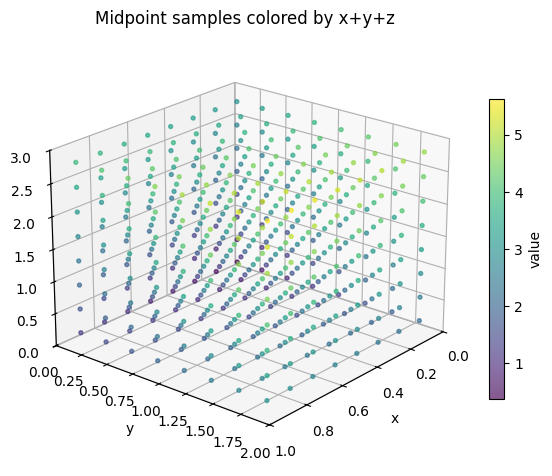

In [3]:
plot_box_points(X, Y, Z, values=W, sample=512, title="Midpoint samples colored by x+y+z")

## 3. Convergence for a nonlinear function

Now use

$$
F(x,y,z)=e^{-(x^2+y^2+z^2)}
$$

over the unit cube $[0,1]^3$.

In [4]:
def F_gaussian3(X, Y, Z):
    return np.exp(-(X**2 + Y**2 + Z**2))

reference, *_ = midpoint_box(F_gaussian3, 0, 1, 0, 1, 0, 1, nx=150, ny=150, nz=150)
print("High-resolution midpoint reference:", reference)

sizes = [6, 10, 16, 24, 36, 50]
print(f"{'n':>6s} {'approximation':>16s} {'error vs ref':>16s}")
for n in sizes:
    val, *_ = midpoint_box(F_gaussian3, 0, 1, 0, 1, 0, 1, nx=n, ny=n, nz=n)
    print(f"{n:6d} {val:16.10f} {val-reference:16.10f}")

High-resolution midpoint reference: 0.41654066571217224
     n    approximation     error vs ref
     6     0.4179672065     0.0014265408
    10     0.4170518543     0.0005111886
    16     0.4167388381     0.0001981724
    24     0.4166274565     0.0000867908
    36     0.4165779691     0.0000373033
    50     0.4165589050     0.0000182393


## 4. Slices of a scalar field

A function of three variables can be visualized by looking at slices.  
For fixed $z=z_0$, we plot

$$
F(x,y,z_0).
$$

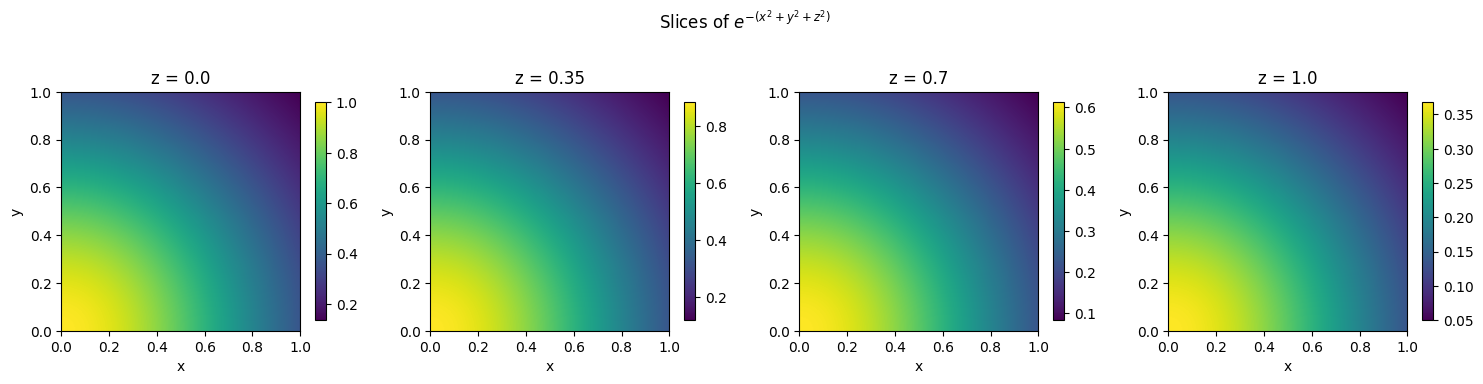

In [5]:
x, y, X2, Y2 = make_grid2d(0, 1, 0, 1, n=250)
z_slices = [0.0, 0.35, 0.7, 1.0]

fig, axes = plt.subplots(1, len(z_slices), figsize=(15, 3.8))
for ax, z0 in zip(axes, z_slices):
    Zval = F_gaussian3(X2, Y2, z0)
    im = ax.imshow(Zval, extent=[0,1,0,1], origin="lower", aspect="equal")
    ax.set_title(f"z = {z0}")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    fig.colorbar(im, ax=ax, shrink=0.7)
plt.suptitle(r"Slices of $e^{-(x^2+y^2+z^2)}$")
plt.tight_layout()
plt.show()

---

# Part II. Iterated integrals and Fubini's theorem

For continuous functions on a box, Fubini's theorem says that the triple integral may be computed by integrating one variable at a time:

$$
\iiint_B F(x,y,z)\,dV
=
\int_a^b\int_c^d\int_e^f F(x,y,z)\,dz\,dy\,dx.
$$

The order may be changed for boxes.

## 5. Numerical iterated integration in different orders

Let

$$
F(x,y,z)=x^2+y+2z
$$

on $[0,1]\times[0,2]\times[0,3]$.

In [6]:
def F_fubini(X, Y, Z):
    return X**2 + Y + 2*Z

# Build a grid and integrate by trapezoid in several axis orders.
x = np.linspace(0, 1, 90)
y = np.linspace(0, 2, 100)
z = np.linspace(0, 3, 110)
Xg, Yg, Zg = np.meshgrid(x, y, z, indexing="ij")
Vals = F_fubini(Xg, Yg, Zg)

# dz dy dx
inner_z = np.trapezoid(Vals, z, axis=2)
inner_zy = np.trapezoid(inner_z, y, axis=1)
val_zyx = np.trapezoid(inner_zy, x, axis=0)

# dx dz dy
inner_x = np.trapezoid(Vals, x, axis=0)
inner_xz = np.trapezoid(inner_x, z, axis=1)
val_xzy = np.trapezoid(inner_xz, y, axis=0)

# Exact:
# volume contribution of x^2: (1/3)*2*3 = 2
# y contribution: 1*(2^2/2)*3 = 6
# 2z contribution: 1*2*(3^2) = 18
exact = 26.0

print("Order dz dy dx:", val_zyx)
print("Order dx dz dy:", val_xzy)
print("Exact value:", exact)
print("Difference between orders:", val_zyx - val_xzy)

Order dz dy dx: 26.000126246686026
Order dx dz dy: 26.000126246686023
Exact value: 26.0
Difference between orders: 3.552713678800501e-15


## 6. Inner integrals as functions

If we integrate first with respect to $z$, the inner integral is

$$
G(x,y)=\int_0^3 (x^2+y+2z)\,dz.
$$

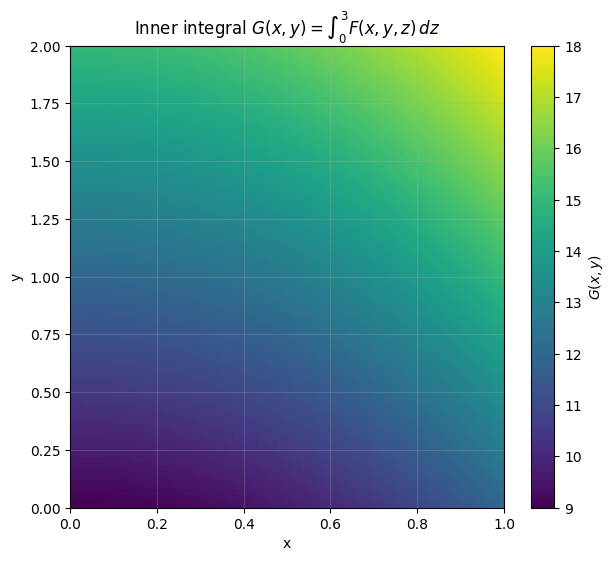

In [7]:
G_xy = inner_z

plt.figure(figsize=(7, 6))
im = plt.imshow(G_xy.T, extent=[0,1,0,2], origin="lower", aspect="auto")
plt.colorbar(im, label=r"$G(x,y)$")
plt.xlabel("x")
plt.ylabel("y")
plt.title(r"Inner integral $G(x,y)=\int_0^3 F(x,y,z)\,dz$")
plt.grid(True, alpha=0.25)
plt.show()

---

# Part III. Volume as a triple integral

When $F=1$,

$$
\iiint_E 1\,dV
$$

is the volume of the solid $E$.

## 7. Volume of a rectangular box

For

$$
B=[0,1]\times[0,2]\times[0,3],
$$

the volume is $1\cdot2\cdot3=6$.

In [8]:
vol_box, X, Y, Z, W, *_ = midpoint_box(one3, 0, 1, 0, 2, 0, 3, nx=20, ny=20, nz=20)
print("Midpoint volume estimate:", vol_box)
print("Exact volume:", 6)

Midpoint volume estimate: 6.0
Exact volume: 6


## 8. Volume of a tetrahedron

Consider the tetrahedron

$$
E=\{(x,y,z):x\ge0,\;y\ge0,\;z\ge0,\;x+y+z\le1\}.
$$

The exact volume is

$$
\frac{1}{6}.
$$

In [9]:
def tetra_mask(X, Y, Z):
    return (X >= 0) & (Y >= 0) & (Z >= 0) & (X + Y + Z <= 1)

for n in [25, 40, 60, 80, 110]:
    vol_tetra, *_ = midpoint_solid_mask(one3, 0, 1, 0, 1, 0, 1, tetra_mask, nx=n, ny=n, nz=n)
    print(f"n={n:4d}, volume estimate={vol_tetra:.8f}, error={vol_tetra-1/6:.8f}")

n=  25, volume estimate=0.16640000, error=-0.00026667
n=  40, volume estimate=0.16656250, error=-0.00010417
n=  60, volume estimate=0.16662037, error=-0.00004630
n=  80, volume estimate=0.16664063, error=-0.00002604
n= 110, volume estimate=0.16665289, error=-0.00001377


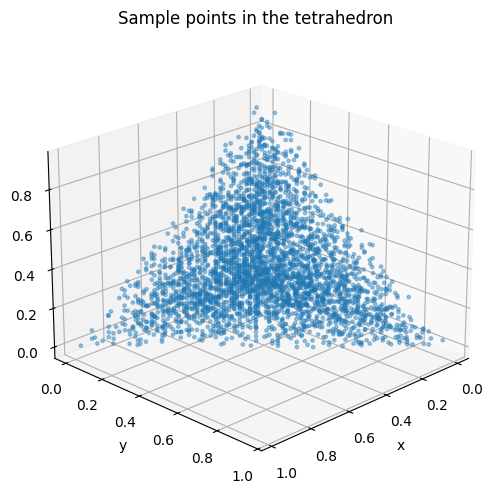

In [10]:
vol_tetra, X, Y, Z, W, inside, *_ = midpoint_solid_mask(
    one3, 0, 1, 0, 1, 0, 1, tetra_mask, nx=70, ny=70, nz=70
)
plot_solid_samples(X, Y, Z, inside, sample=3500, title="Sample points in the tetrahedron")

## 9. Volume of a ball

The ball of radius $R$ is

$$
x^2+y^2+z^2\le R^2.
$$

Its exact volume is

$$
\frac{4}{3}\pi R^3.
$$

In [11]:
def ball_mask_radius(R):
    return lambda X, Y, Z: X**2 + Y**2 + Z**2 <= R**2

R = 1.0
ball_mask = ball_mask_radius(R)

for n in [35, 55, 75, 95]:
    vol_ball, *_ = midpoint_solid_mask(one3, -R, R, -R, R, -R, R, ball_mask, nx=n, ny=n, nz=n)
    print(f"n={n:4d}, volume estimate={vol_ball:.8f}, error={vol_ball-(4*np.pi/3):.8f}")

exact_ball = 4*np.pi/3
print("Exact ball volume:", exact_ball)

n=  35, volume estimate=4.21224490, error=0.02345469
n=  55, volume estimate=4.19635162, error=0.00756141
n=  75, volume estimate=4.19307141, error=0.00428120
n=  95, volume estimate=4.18817903, error=-0.00061117
Exact ball volume: 4.1887902047863905


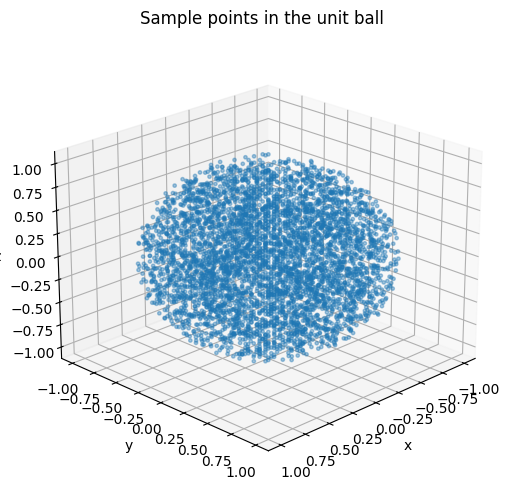

In [12]:
vol_ball, X, Y, Z, W, inside, *_ = midpoint_solid_mask(
    one3, -1, 1, -1, 1, -1, 1, ball_mask, nx=65, ny=65, nz=65
)
plot_solid_samples(X, Y, Z, inside, sample=5000, title="Sample points in the unit ball")

---

# Part IV. Solids between surfaces

A common solid has the form

$$
E=\{(x,y,z):(x,y)\in D,\;g_1(x,y)\le z\le g_2(x,y)\}.
$$

Then

$$
\iiint_E F(x,y,z)\,dV
=
\iint_D\int_{g_1(x,y)}^{g_2(x,y)}F(x,y,z)\,dz\,dA.
$$

## 10. Solid under a plane above a rectangle

Let

$$
0\le x\le1,\qquad 0\le y\le2,\qquad 0\le z\le 1+x+y.
$$

Its volume is

$$
\int_0^1\int_0^2(1+x+y)\,dy\,dx.
$$

In [13]:
z_lower_plane = lambda x, y: 0*x + 0*y
z_upper_plane = lambda x, y: 1 + x + y

vol_under_plane = integrate_between_surfaces(
    one3,
    0, 1,
    0, 2,
    z_lower_plane,
    z_upper_plane,
    nx=160,
    ny=160,
    nz=20
)

# Exact: ∫_0^1∫_0^2 (1+x+y) dy dx = ∫_0^1 (4+2x) dx = 5
exact = 5.0

print("Volume estimate:", vol_under_plane)
print("Exact volume:", exact)

Volume estimate: 5.000000000000014
Exact volume: 5.0


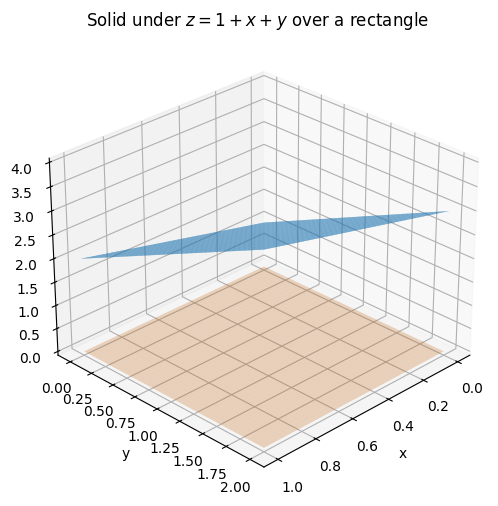

In [14]:
x, y, X2, Y2 = make_grid2d(0, 1, 0, 2, n=120)
Ztop = z_upper_plane(X2, Y2)

fig, ax = make_3d_axes(title=r"Solid under $z=1+x+y$ over a rectangle", elev=28, azim=45)
ax.plot_surface(X2, Y2, Ztop, linewidth=0, alpha=0.75)
ax.plot_surface(X2, Y2, 0*Ztop, linewidth=0, alpha=0.25)
plt.show()

## 11. Solid between a paraboloid and the plane $z=0$

Let

$$
E=\{(x,y,z):x^2+y^2\le1,\;0\le z\le 1-x^2-y^2\}.
$$

The exact volume is

$$
\iint_{x^2+y^2\le1}(1-x^2-y^2)\,dA
=
\frac{\pi}{2}.
$$

In [15]:
def disk_mask_xy(x, y):
    return x**2 + y**2 <= 1

z_top_paraboloid = lambda x, y: 1 - x**2 - y**2

vol_paraboloid = integrate_between_surfaces(
    one3,
    -1, 1,
    -1, 1,
    lambda x, y: 0,
    z_top_paraboloid,
    mask_xy=disk_mask_xy,
    nx=180,
    ny=180,
    nz=30
)

print("Volume estimate:", vol_paraboloid)
print("Exact volume:", np.pi/2)
print("Error:", vol_paraboloid - np.pi/2)

Volume estimate: 1.5708000000000042
Exact volume: 1.5707963267948966
Error: 3.6732051076349137e-06


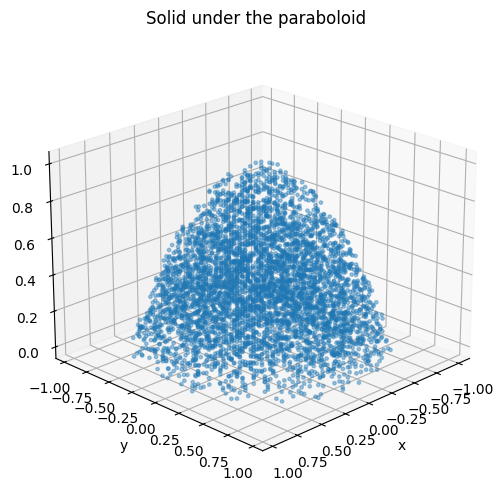

In [16]:
def paraboloid_solid_mask(X, Y, Z):
    return (X**2 + Y**2 <= 1) & (Z >= 0) & (Z <= 1 - X**2 - Y**2)

vol_para, X, Y, Z, W, inside, *_ = midpoint_solid_mask(
    one3, -1, 1, -1, 1, 0, 1, paraboloid_solid_mask, nx=70, ny=70, nz=70
)
plot_solid_samples(X, Y, Z, inside, sample=5000, title="Solid under the paraboloid")

## 12. Surface plot of the paraboloid cap

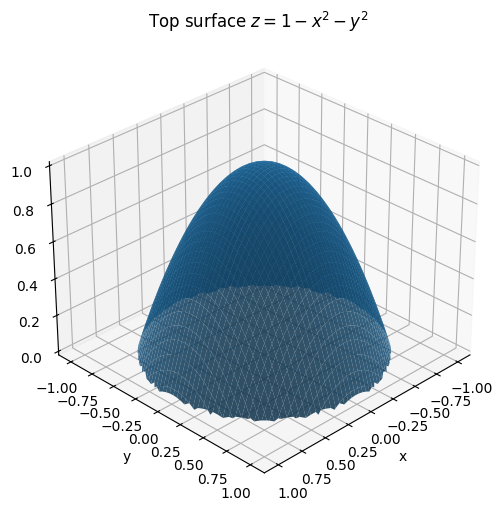

In [17]:
x, y, X2, Y2 = make_grid2d(-1, 1, -1, 1, n=150)
R2 = X2**2 + Y2**2
Ztop = np.where(R2 <= 1, 1 - R2, np.nan)

fig, ax = make_3d_axes(title=r"Top surface $z=1-x^2-y^2$", elev=30, azim=45)
ax.plot_surface(X2, Y2, Ztop, linewidth=0, alpha=0.85)
plt.show()

---

# Part V. Type I, Type II, and Type III solids

In three dimensions, a solid can often be described by choosing one variable as the inner variable.

For example, a $z$-simple solid has

$$
(x,y)\in D,\qquad g_1(x,y)\le z\le g_2(x,y).
$$

But a problem may be easier if sliced by $x$ or $y$ instead.

## 13. Rewriting a tetrahedron

The tetrahedron

$$
x\ge0,\quad y\ge0,\quad z\ge0,\quad x+y+z\le1
$$

can be written as

$$
0\le x\le1,\qquad
0\le y\le1-x,\qquad
0\le z\le1-x-y.
$$

Thus

$$
\iiint_E 1\,dV
=
\int_0^1\int_0^{1-x}\int_0^{1-x-y}1\,dz\,dy\,dx.
$$

In [18]:
def tetra_iterated_volume(nx=800, ny=400):
    xs = np.linspace(0, 1, nx)
    outer_values = []
    for x0 in xs:
        ys = np.linspace(0, 1-x0, ny)
        inner = 1 - x0 - ys
        outer_values.append(np.trapezoid(inner, ys))
    return float(np.trapezoid(outer_values, xs))

tetra_vol_iter = tetra_iterated_volume(nx=1000, ny=500)

print("Iterated integral volume:", tetra_vol_iter)
print("Exact volume:", 1/6)

Iterated integral volume: 0.166666750166917
Exact volume: 0.16666666666666666


## 14. Integrate a function over the tetrahedron

Compute

$$
\iiint_E (x+y+z)\,dV.
$$

By symmetry, the result is

$$
3\iiint_E x\,dV.
$$

For the standard tetrahedron, the centroid is $(1/4,1/4,1/4)$ and volume is $1/6$, so

$$
\iiint_E(x+y+z)\,dV
=
\frac34\cdot\frac16
=
\frac18.
$$

In [19]:
val_tetra_sum, X, Y, Z, W, inside, *_ = midpoint_solid_mask(
    F_linear,
    0, 1, 0, 1, 0, 1,
    tetra_mask,
    nx=95, ny=95, nz=95
)

print("Midpoint masked estimate:", val_tetra_sum)
print("Exact value:", 1/8)
print("Error:", val_tetra_sum - 1/8)

Midpoint masked estimate: 0.12498614958448753
Exact value: 0.125
Error: -1.3850415512467462e-05


---

# Part VI. Mass and density

If a solid $E$ has density $\rho(x,y,z)$, then mass is

$$
m=\iiint_E \rho(x,y,z)\,dV.
$$

The center of mass is

$$
\bar x=\frac1m\iiint_E x\rho\,dV,\qquad
\bar y=\frac1m\iiint_E y\rho\,dV,\qquad
\bar z=\frac1m\iiint_E z\rho\,dV.
$$

## 15. Density in a rectangular box

Let

$$
B=[0,1]\times[0,1]\times[0,1],
\qquad
\rho(x,y,z)=1+x+y+z.
$$

Compute mass and center of mass.

In [20]:
def rho_cube(X, Y, Z):
    return 1 + X + Y + Z

mass, *_ = midpoint_box(rho_cube, 0, 1, 0, 1, 0, 1, nx=100, ny=100, nz=100)
Mx, *_ = midpoint_box(lambda X, Y, Z: X*rho_cube(X, Y, Z), 0, 1, 0, 1, 0, 1, nx=100, ny=100, nz=100)
My, *_ = midpoint_box(lambda X, Y, Z: Y*rho_cube(X, Y, Z), 0, 1, 0, 1, 0, 1, nx=100, ny=100, nz=100)
Mz, *_ = midpoint_box(lambda X, Y, Z: Z*rho_cube(X, Y, Z), 0, 1, 0, 1, 0, 1, nx=100, ny=100, nz=100)

center = np.array([Mx/mass, My/mass, Mz/mass])

print("Mass:", mass)
print("Center of mass:", center)

# Exact:
# mass = 1 + 1/2 + 1/2 + 1/2 = 5/2.
# x moment = ∫ x(1+x+y+z)=1/2+1/3+1/4+1/4 = 4/3.
# xbar = (4/3)/(5/2)=8/15.
print("Exact mass:", 2.5)
print("Exact center:", np.array([8/15, 8/15, 8/15]))

Mass: 2.5
Center of mass: [0.53333 0.53333 0.53333]
Exact mass: 2.5
Exact center: [0.533333 0.533333 0.533333]


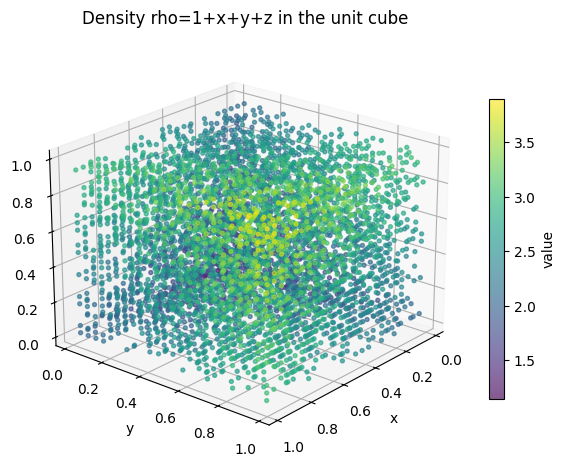

In [21]:
_, X, Y, Z, RHO, *_ = midpoint_box(rho_cube, 0, 1, 0, 1, 0, 1, nx=24, ny=24, nz=24)
plot_box_points(X, Y, Z, values=RHO, sample=5000, title="Density rho=1+x+y+z in the unit cube")

## 16. Density in a ball

Let

$$
E=\{x^2+y^2+z^2\le1\},
\qquad
\rho(x,y,z)=1+z.
$$

Because density is larger near the top, the center of mass should have positive $\bar z$.

In [22]:
def rho_ball(X, Y, Z):
    return 1 + Z

mass_ball, X, Y, Z, W, inside, *_ = midpoint_solid_mask(
    rho_ball,
    -1, 1, -1, 1, -1, 1,
    ball_mask,
    nx=85, ny=85, nz=85
)

Mx_ball, *_ = midpoint_solid_mask(lambda X, Y, Z: X*rho_ball(X, Y, Z), -1, 1, -1, 1, -1, 1, ball_mask, nx=85, ny=85, nz=85)
My_ball, *_ = midpoint_solid_mask(lambda X, Y, Z: Y*rho_ball(X, Y, Z), -1, 1, -1, 1, -1, 1, ball_mask, nx=85, ny=85, nz=85)
Mz_ball, *_ = midpoint_solid_mask(lambda X, Y, Z: Z*rho_ball(X, Y, Z), -1, 1, -1, 1, -1, 1, ball_mask, nx=85, ny=85, nz=85)

center_ball = np.array([Mx_ball/mass_ball, My_ball/mass_ball, Mz_ball/mass_ball])

print("Mass estimate:", mass_ball)
print("Center of mass estimate:", center_ball)

# Exact mass: ∫_ball 1 dV + ∫ z dV = 4π/3.
# z moment: ∫ z(1+z)dV = ∫ z^2 dV = 4π/15.
# zbar = (4π/15)/(4π/3)=1/5.
print("Exact center:", np.array([0, 0, 1/5]))

Mass estimate: 4.191732953388968
Center of mass estimate: [-0.       -0.        0.200094]
Exact center: [0.  0.  0.2]


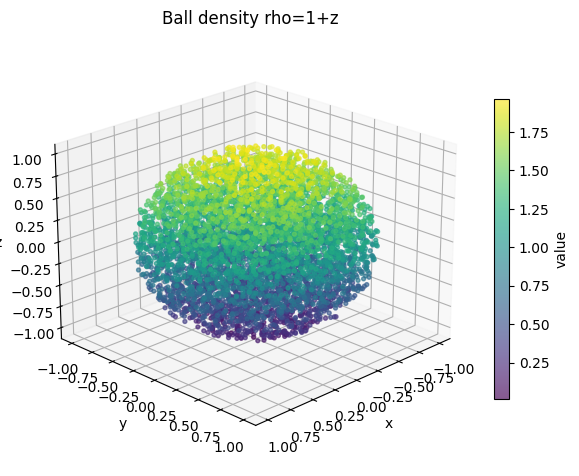

In [23]:
plot_solid_samples(X, Y, Z, inside, values=W, sample=6000, title="Ball density rho=1+z")

---

# Part VII. Average value over a solid

The average value of $F$ over a solid $E$ is

$$
F_{\text{avg}}
=
\frac{1}{\operatorname{Vol}(E)}
\iiint_E F(x,y,z)\,dV.
$$

## 17. Average value of $x^2+y^2+z^2$ in the unit ball

By symmetry and spherical coordinates,

$$
\frac{1}{\operatorname{Vol}(B)}
\iiint_B (x^2+y^2+z^2)\,dV
=
\frac{3}{5}.
$$

In [24]:
def radius_squared3(X, Y, Z):
    return X**2 + Y**2 + Z**2

integral_r2_ball, *_ = midpoint_solid_mask(
    radius_squared3,
    -1, 1, -1, 1, -1, 1,
    ball_mask,
    nx=90, ny=90, nz=90
)

volume_ball, *_ = midpoint_solid_mask(
    one3,
    -1, 1, -1, 1, -1, 1,
    ball_mask,
    nx=90, ny=90, nz=90
)

avg_r2_ball = integral_r2_ball/volume_ball

print("Integral estimate:", integral_r2_ball)
print("Volume estimate:", volume_ball)
print("Average value estimate:", avg_r2_ball)
print("Exact average value:", 3/5)

Integral estimate: 2.52021653609714
Volume estimate: 4.195731138545954
Average value estimate: 0.6006620664856354
Exact average value: 0.6


## 18. Slice averages in the unit ball

At height $z=z_0$, the cross-section is a disk of radius

$$
\sqrt{1-z_0^2}.
$$

We can visualize how cross-sectional area changes with $z$.

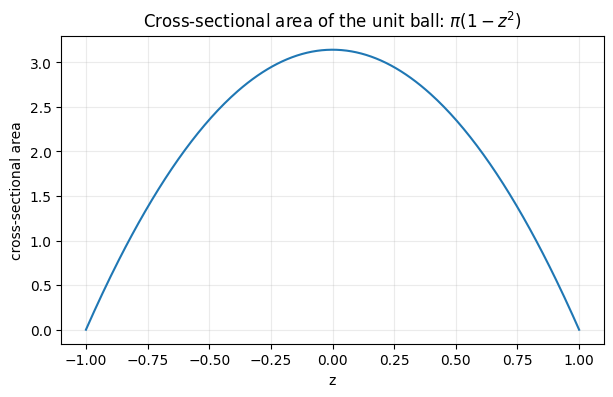

Volume from slicing: 4.188743350833921
Exact volume: 4.1887902047863905


In [25]:
z_values = np.linspace(-1, 1, 300)
cross_section_area = np.pi*(1 - z_values**2)

plt.figure(figsize=(7, 4))
plt.plot(z_values, cross_section_area)
plt.xlabel("z")
plt.ylabel("cross-sectional area")
plt.title(r"Cross-sectional area of the unit ball: $\pi(1-z^2)$")
plt.grid(True, alpha=0.25)
plt.show()

volume_from_slices = np.trapezoid(cross_section_area, z_values)
print("Volume from slicing:", volume_from_slices)
print("Exact volume:", 4*np.pi/3)

---

# Part VIII. Monte Carlo integration in 3D

Monte Carlo integration estimates

$$
\iiint_E F\,dV
$$

by random sampling in a bounding box.

If $B$ contains $E$, then

$$
\iiint_E F\,dV
=
\operatorname{Vol}(B)\,
\mathbb E[F(X,Y,Z)\mathbf 1_E(X,Y,Z)].
$$

## 19. Monte Carlo estimate of ball volume

In [26]:
sample_sizes = [2_000, 10_000, 50_000, 200_000, 500_000]

print(f"{'n':>10s} {'estimate':>14s} {'std error':>14s} {'error':>14s}")
for n in sample_sizes:
    est, se, *_ = monte_carlo_solid(
        one3,
        -1, 1, -1, 1, -1, 1,
        mask=ball_mask,
        n=n,
        seed=1600+n
    )
    print(f"{n:10d} {est:14.8f} {se:14.8f} {est-4*np.pi/3:14.8f}")

         n       estimate      std error          error
      2000     4.26400000     0.08927002     0.07520980
     10000     4.22400000     0.03993923     0.03520980
     50000     4.17456000     0.01787168    -0.01423020
    200000     4.17984000     0.00893525    -0.00895020
    500000     4.18665600     0.00565070    -0.00213420


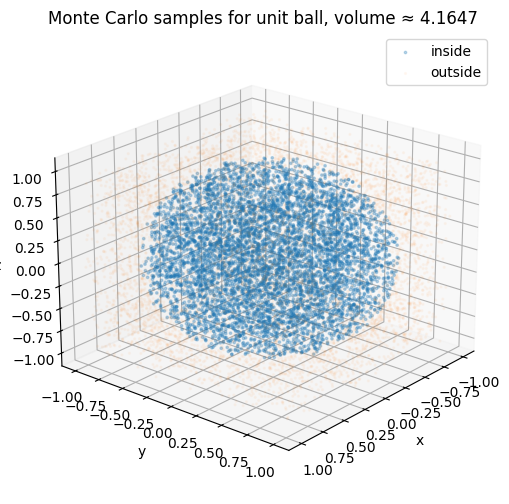

In [27]:
est, se, Xs, Ys, Zs, inside, vals = monte_carlo_solid(
    one3,
    -1, 1, -1, 1, -1, 1,
    mask=ball_mask,
    n=12000,
    seed=1616
)

fig, ax = make_3d_axes(title=f"Monte Carlo samples for unit ball, volume ≈ {est:.4f}", elev=22, azim=40)
ax.scatter(Xs[inside], Ys[inside], Zs[inside], s=3, alpha=0.28, label="inside")
ax.scatter(Xs[~inside], Ys[~inside], Zs[~inside], s=2, alpha=0.04, label="outside")
ax.legend()
plt.show()

## 20. Monte Carlo estimate of a mass integral

Estimate

$$
\iiint_{x^2+y^2+z^2\le1}(1+z)\,dV.
$$

In [28]:
exact_mass_ball = 4*np.pi/3

for n in [5_000, 20_000, 100_000, 400_000]:
    est, se, *_ = monte_carlo_solid(
        rho_ball,
        -1, 1, -1, 1, -1, 1,
        mask=ball_mask,
        n=n,
        seed=1620+n
    )
    print(f"n={n:8d}, mass estimate={est:.8f}, SE={se:.8f}, error={est-exact_mass_ball:.8f}")

n=    5000, mass estimate=4.07143763, SE=0.06654114, error=-0.11735258
n=   20000, mass estimate=4.12636445, SE=0.03365126, error=-0.06242576
n=  100000, mass estimate=4.17707433, SE=0.01508743, error=-0.01171587
n=  400000, mass estimate=4.17873002, SE=0.00752139, error=-0.01006018


### Interpretation

Monte Carlo methods converge slowly, but they are flexible for irregular 3D solids where deterministic slicing is difficult.

---

# Part IX. Probability interpretation

If $f(x,y,z)$ is a joint density, then

$$
P((X,Y,Z)\in E)=\iiint_E f(x,y,z)\,dV.
$$

For a uniform distribution on a solid, probability is proportional to volume.

## 21. Uniform distribution in the unit cube

Let $(X,Y,Z)$ be uniform on $[0,1]^3$.  
Find

$$
P(X+Y+Z\le1).
$$

This is the volume of the standard tetrahedron, so the answer is $1/6$.

In [29]:
prob_tetra, *_ = midpoint_solid_mask(
    one3,
    0, 1, 0, 1, 0, 1,
    tetra_mask,
    nx=95, ny=95, nz=95
)

mc_prob, mc_se, *_ = monte_carlo_solid(
    one3,
    0, 1, 0, 1, 0, 1,
    mask=tetra_mask,
    n=300_000,
    seed=1630
)

print("Grid probability estimate:", prob_tetra)
print("Monte Carlo probability estimate:", mc_prob)
print("Monte Carlo standard error:", mc_se)
print("Exact probability:", 1/6)

Grid probability estimate: 0.16664819944598336
Monte Carlo probability estimate: 0.16680333333333333
Monte Carlo standard error: 0.0006806380452447317
Exact probability: 0.16666666666666666


## 22. A nonuniform density in a cube

Let

$$
f(x,y,z)=8xyz
$$

on $[0,1]^3$.

This is a probability density because

$$
\int_0^1\int_0^1\int_0^1 8xyz\,dz\,dy\,dx=1.
$$

Compute

$$
P(X+Y+Z\le1).
$$

In [30]:
def density_8xyz(X, Y, Z):
    return 8*X*Y*Z

total_density, *_ = midpoint_box(density_8xyz, 0, 1, 0, 1, 0, 1, nx=80, ny=80, nz=80)
prob_weighted, *_ = midpoint_solid_mask(density_8xyz, 0, 1, 0, 1, 0, 1, tetra_mask, nx=100, ny=100, nz=100)

print("Total density integral over cube:", total_density)
print("Probability estimate for X+Y+Z <= 1:", prob_weighted)

# Exact: 8∫_{simplex} xyz dV = 8*(1!1!1!)/(6!) = 8/720 = 1/90.
print("Exact probability:", 1/90)

Total density integral over cube: 1.0
Probability estimate for X+Y+Z <= 1: 0.011113888500000002
Exact probability: 0.011111111111111112


---

# Part X. Geometry workflow for triple integrals

A useful workflow for triple integrals is:

1. identify the solid $E$;
2. choose a slicing direction;
3. write inner limits first;
4. project onto a lower-dimensional region;
5. compute or approximate the integral;
6. check with a second method if possible.

## 23. Workflow example: cone inside a cylinder

Consider the solid

$$
E=\{(x,y,z):x^2+y^2\le1,\;0\le z\le \sqrt{x^2+y^2}\}.
$$

This is the region under the cone $z=\sqrt{x^2+y^2}$ and above the disk.

The exact volume is easiest in polar/cylindrical thinking:

$$
\int_0^{2\pi}\int_0^1\int_0^r r\,dz\,dr\,d\theta
=
\frac{2\pi}{3}.
$$

In [31]:
def cone_solid_mask(X, Y, Z):
    R = np.sqrt(X**2 + Y**2)
    return (R <= 1) & (Z >= 0) & (Z <= R)

vol_cone_grid, X, Y, Z, W, inside, *_ = midpoint_solid_mask(
    one3,
    -1, 1, -1, 1, 0, 1,
    cone_solid_mask,
    nx=80, ny=80, nz=80
)

print("Mask-grid volume estimate:", vol_cone_grid)
print("Exact volume:", 2*np.pi/3)
print("Error:", vol_cone_grid - 2*np.pi/3)

Mask-grid volume estimate: 2.092
Exact volume: 2.0943951023931953
Error: -0.002395102393195181


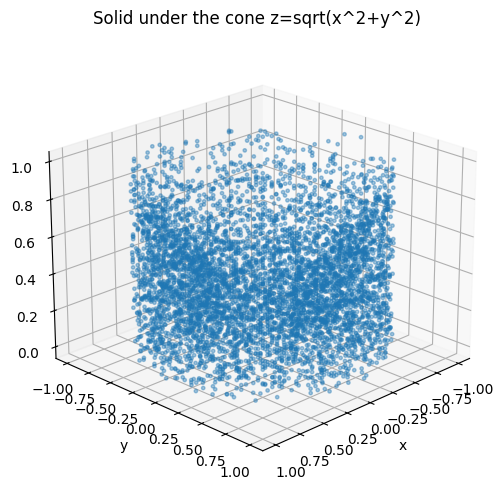

In [32]:
plot_solid_samples(X, Y, Z, inside, sample=6000, title="Solid under the cone z=sqrt(x^2+y^2)")

## 24. Slice view of the cone solid

At height $z$, the condition $z\le r\le1$ gives an annulus with area

$$
\pi(1^2-z^2).
$$

Thus the volume is

$$
\int_0^1 \pi(1-z^2)\,dz
=
\frac{2\pi}{3}.
$$

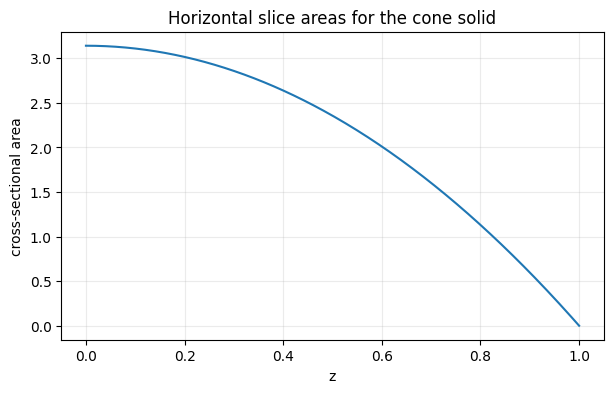

Volume by integrating slice areas: 2.094391813476822
Exact volume: 2.0943951023931953


In [33]:
z_values = np.linspace(0, 1, 400)
area_slices = np.pi*(1 - z_values**2)
volume_by_z_slices = np.trapezoid(area_slices, z_values)

plt.figure(figsize=(7, 4))
plt.plot(z_values, area_slices)
plt.xlabel("z")
plt.ylabel("cross-sectional area")
plt.title("Horizontal slice areas for the cone solid")
plt.grid(True, alpha=0.25)
plt.show()

print("Volume by integrating slice areas:", volume_by_z_slices)
print("Exact volume:", 2*np.pi/3)

---

# Part XI. Chapter mini-project: mass of an irregular 3D object

In applications, a solid may be defined by data or a mask rather than clean equations.

Consider the irregular solid

$$
E=\{(x,y,z):-1.5\le x,y,z\le1.5,\;
x^2+y^2+z^2\le 1+0.25\sin(3x)\cos(2y)+0.15z\}.
$$

Let the density be

$$
\rho(x,y,z)=2+0.4x-0.2y+0.3z.
$$

You will estimate:

1. the volume of $E$;
2. the mass of $E$;
3. the center of mass;
4. the average density;
5. a Monte Carlo check.

## 25. Define the irregular solid and density

In [34]:
def irregular3_mask(X, Y, Z):
    boundary = 1 + 0.25*np.sin(3*X)*np.cos(2*Y) + 0.15*Z
    return X**2 + Y**2 + Z**2 <= boundary

def rho_irregular(X, Y, Z):
    return 2 + 0.4*X - 0.2*Y + 0.3*Z

xmin, xmax = -1.5, 1.5
ymin, ymax = -1.5, 1.5
zmin, zmax = -1.5, 1.5

volume_irreg, X, Y, Z, W, inside, *_ = midpoint_solid_mask(
    one3,
    xmin, xmax, ymin, ymax, zmin, zmax,
    irregular3_mask,
    nx=75, ny=75, nz=75
)

mass_irreg, *_ = midpoint_solid_mask(
    rho_irregular,
    xmin, xmax, ymin, ymax, zmin, zmax,
    irregular3_mask,
    nx=75, ny=75, nz=75
)

Mx_irreg, *_ = midpoint_solid_mask(lambda X, Y, Z: X*rho_irregular(X, Y, Z),
                                   xmin, xmax, ymin, ymax, zmin, zmax,
                                   irregular3_mask, nx=75, ny=75, nz=75)
My_irreg, *_ = midpoint_solid_mask(lambda X, Y, Z: Y*rho_irregular(X, Y, Z),
                                   xmin, xmax, ymin, ymax, zmin, zmax,
                                   irregular3_mask, nx=75, ny=75, nz=75)
Mz_irreg, *_ = midpoint_solid_mask(lambda X, Y, Z: Z*rho_irregular(X, Y, Z),
                                   xmin, xmax, ymin, ymax, zmin, zmax,
                                   irregular3_mask, nx=75, ny=75, nz=75)

center_irreg = np.array([Mx_irreg/mass_irreg, My_irreg/mass_irreg, Mz_irreg/mass_irreg])
avg_density_irreg = mass_irreg/volume_irreg

print("Volume estimate:", volume_irreg)
print("Mass estimate:", mass_irreg)
print("Center of mass estimate:", center_irreg)
print("Average density:", avg_density_irreg)

Volume estimate: 4.197184
Mass estimate: 8.601157376
Center of mass estimate: [ 0.104879 -0.019884  0.105376]
Average density: 2.049268599136945


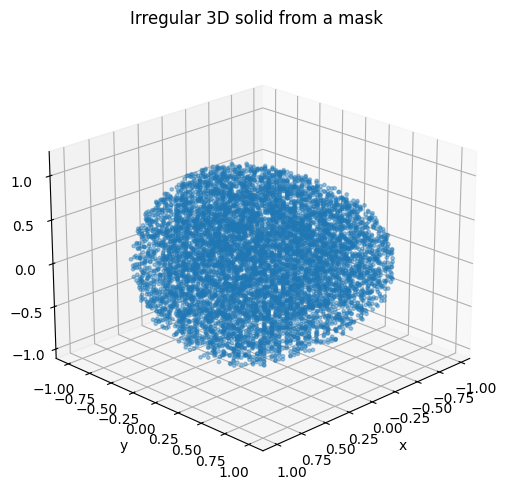

In [35]:
plot_solid_samples(X, Y, Z, inside, sample=8000, title="Irregular 3D solid from a mask")

## 26. Density-colored sample of the irregular solid

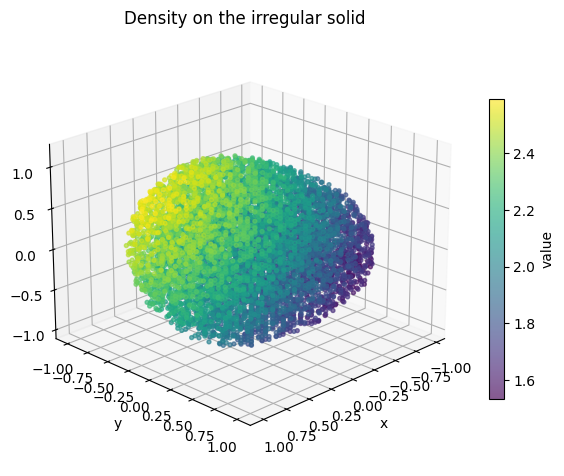

In [36]:
RHO = rho_irregular(X, Y, Z)
plot_solid_samples(X, Y, Z, inside, values=RHO, sample=8000, title="Density on the irregular solid")

## 27. Monte Carlo check

In [37]:
for n in [20_000, 80_000, 250_000, 600_000]:
    vol_mc, vol_se, *_ = monte_carlo_solid(
        one3,
        xmin, xmax, ymin, ymax, zmin, zmax,
        mask=irregular3_mask,
        n=n,
        seed=1640+n
    )
    mass_mc, mass_se, *_ = monte_carlo_solid(
        rho_irregular,
        xmin, xmax, ymin, ymax, zmin, zmax,
        mask=irregular3_mask,
        n=n,
        seed=1650+n
    )
    print(f"n={n:8d}  volume={vol_mc:10.6f}  vol SE={vol_se:9.6f}  mass={mass_mc:10.6f}  mass SE={mass_se:9.6f}")

n=   20000  volume=  4.108050  vol SE= 0.068573  mass=  8.562760  mass SE= 0.142892
n=   80000  volume=  4.181287  vol SE= 0.034535  mass=  8.647271  mass SE= 0.071589
n=  250000  volume=  4.181112  vol SE= 0.019535  mass=  8.603416  mass SE= 0.040445
n=  600000  volume=  4.208940  vol SE= 0.012644  mass=  8.581772  mass SE= 0.026067


## 28. Mini-project questions

Answer the following in a markdown cell:

1. Why is a mask-based method natural for this irregular solid?
2. What does the center of mass tell you about how density is distributed?
3. How does the Monte Carlo standard error change as sample size increases?
4. Which estimate appears more stable: volume or mass?
5. How would you improve accuracy without changing the mathematical model?

In [38]:
print("Mini-project summary")
print("--------------------")
print("Volume:", volume_irreg)
print("Mass:", mass_irreg)
print("Average density:", avg_density_irreg)
print("Center of mass:", center_irreg)
print("Bounding box volume:", (xmax-xmin)*(ymax-ymin)*(zmax-zmin))
print("Fraction of bounding box occupied:", volume_irreg/((xmax-xmin)*(ymax-ymin)*(zmax-zmin)))

Mini-project summary
--------------------
Volume: 4.197184
Mass: 8.601157376
Average density: 2.049268599136945
Center of mass: [ 0.104879 -0.019884  0.105376]
Bounding box volume: 27.0
Fraction of bounding box occupied: 0.15545125925925926


---

# Part XII. Additional exercises with reference solutions

Try each exercise before running the reference solution.

## Exercise A. Box integral

Approximate

$$
\iiint_{[0,1]\times[0,2]\times[0,1]}(x^2+y+z^2)\,dV
$$

using midpoint sums. Compare with the exact value.

In [39]:
# Exercise A workspace

# Your code here

### Reference solution for Exercise A

In [40]:
def exercise_A_F(X, Y, Z):
    return X**2 + Y + Z**2

val_A, *_ = midpoint_box(exercise_A_F, 0, 1, 0, 2, 0, 1, nx=60, ny=60, nz=60)

# Exact:
# x^2 contribution: (1/3)*2*1 = 2/3
# y contribution: 1*(2^2/2)*1 = 2
# z^2 contribution: 1*2*(1/3)=2/3
exact_A = 10/3

print("Midpoint estimate:", val_A)
print("Exact value:", exact_A)
print("Error:", val_A - exact_A)

Midpoint estimate: 3.3332407407407407
Exact value: 3.3333333333333335
Error: -9.25925925927551e-05


## Exercise B. Tetrahedron volume

Use a 3D mask to approximate the volume of

$$
x\ge0,\quad y\ge0,\quad z\ge0,\quad 2x+y+z\le1.
$$

In [41]:
# Exercise B workspace

# Your code here

### Reference solution for Exercise B

In [42]:
def exercise_B_mask(X, Y, Z):
    return (X >= 0) & (Y >= 0) & (Z >= 0) & (2*X + Y + Z <= 1)

vol_B, *_ = midpoint_solid_mask(one3, 0, 0.5, 0, 1, 0, 1, exercise_B_mask, nx=80, ny=80, nz=80)

# Intercepts are 1/2, 1, 1, so volume = (1/6)(1/2)(1)(1)=1/12.
print("Volume estimate:", vol_B)
print("Exact volume:", 1/12)

Volume estimate: 0.08332031250000001
Exact volume: 0.08333333333333333


## Exercise C. Ball average

Approximate the average value of

$$
F(x,y,z)=z^2
$$

over the unit ball. The exact value is $1/5$.

In [43]:
# Exercise C workspace

# Your code here

### Reference solution for Exercise C

In [44]:
val_C, *_ = midpoint_solid_mask(lambda X, Y, Z: Z**2, -1, 1, -1, 1, -1, 1, ball_mask, nx=90, ny=90, nz=90)
vol_C, *_ = midpoint_solid_mask(one3, -1, 1, -1, 1, -1, 1, ball_mask, nx=90, ny=90, nz=90)
avg_C = val_C/vol_C

print("Average estimate:", avg_C)
print("Exact average:", 1/5)

Average estimate: 0.20022068882854513
Exact average: 0.2


## Exercise D. Solid between surfaces

Compute the volume of

$$
0\le z\le 4-x^2-y^2
$$

over the disk

$$
x^2+y^2\le4.
$$

In [45]:
# Exercise D workspace

# Your code here

### Reference solution for Exercise D

In [46]:
def disk_radius2_xy(x, y):
    return x**2 + y**2 <= 4

val_D = integrate_between_surfaces(
    one3,
    -2, 2,
    -2, 2,
    lambda x, y: 0,
    lambda x, y: 4 - x**2 - y**2,
    mask_xy=disk_radius2_xy,
    nx=220,
    ny=220,
    nz=30
)

# Exact polar: ∫_0^{2π}∫_0^2 (4-r^2) r dr dtheta = 8π.
print("Volume estimate:", val_D)
print("Exact volume:", 8*np.pi)

Volume estimate: 25.132793005941956
Exact volume: 25.132741228718345


## Exercise E. Probability in a cube

Let $(X,Y,Z)$ be uniform on $[0,1]^3$. Estimate

$$
P(X^2+Y^2+Z^2\le1).
$$

Compare with the exact value $\pi/6$, the volume of one octant of the unit ball.

In [47]:
# Exercise E workspace

# Your code here

### Reference solution for Exercise E

In [48]:
def octant_ball_mask(X, Y, Z):
    return (0 <= X) & (X <= 1) & (0 <= Y) & (Y <= 1) & (0 <= Z) & (Z <= 1) & (X**2 + Y**2 + Z**2 <= 1)

prob_E, *_ = midpoint_solid_mask(one3, 0, 1, 0, 1, 0, 1, octant_ball_mask, nx=90, ny=90, nz=90)
mc_E, se_E, *_ = monte_carlo_solid(one3, 0, 1, 0, 1, 0, 1, mask=octant_ball_mask, n=300_000, seed=1690)

print("Grid estimate:", prob_E)
print("Monte Carlo estimate:", mc_E)
print("Monte Carlo SE:", se_E)
print("Exact value:", np.pi/6)

Grid estimate: 0.5236351165980796
Monte Carlo estimate: 0.5243633333333333
Monte Carlo SE: 0.0009117880955324725
Exact value: 0.5235987755982988


---

# Formula summary

## Triple integral

$$
\iiint_E F(x,y,z)\,dV.
$$

## Volume

$$
\operatorname{Vol}(E)=\iiint_E1\,dV.
$$

## Rectangular box

For

$$
B=[a,b]\times[c,d]\times[e,f],
$$

$$
\iiint_B F\,dV
=
\int_a^b\int_c^d\int_e^f F(x,y,z)\,dz\,dy\,dx.
$$

## Solid between surfaces

If

$$
E=\{(x,y,z):(x,y)\in D,\;g_1(x,y)\le z\le g_2(x,y)\},
$$

then

$$
\iiint_EF\,dV
=
\iint_D\int_{g_1(x,y)}^{g_2(x,y)}F(x,y,z)\,dz\,dA.
$$

## Mass

$$
m=\iiint_E \rho(x,y,z)\,dV.
$$

## Center of mass

$$
\bar x=\frac1m\iiint_E x\rho\,dV,
\qquad
\bar y=\frac1m\iiint_E y\rho\,dV,
\qquad
\bar z=\frac1m\iiint_E z\rho\,dV.
$$

## Average value

$$
F_{\operatorname{avg}}
=
\frac{1}{\operatorname{Vol}(E)}
\iiint_EF\,dV.
$$

## Monte Carlo integration

If $B$ is a bounding box containing $E$,

$$
\iiint_EF\,dV
=
\operatorname{Vol}(B)\,
\mathbb E[F(X,Y,Z)\mathbf 1_E(X,Y,Z)].
$$

# End of Chapter 16 Lab

You have used Python to explore:

- triple integrals and 3D Riemann sums,
- iterated integrals over boxes,
- volume as $\iiint_E1\,dV$,
- tetrahedra, balls, cones, and solids between surfaces,
- mass and density,
- center of mass,
- average value over a solid,
- slicing geometry,
- probability interpretation,
- Monte Carlo integration,
- and an irregular-solid mini-project.

These ideas prepare for cylindrical and spherical coordinates, vector fields in space, surface integrals, flux, and the major theorems of vector calculus.